## TODO

new dataset

In [60]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator
from sklearn.preprocessing import StandardScaler

from torch.utils.data import Dataset
import torch
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [61]:
class ManyToManyOverlappingDataset(Dataset):
    def __init__(self, X, y, flight_ids, indices, window_size, stride=1):
        self.X = torch.tensor(X, dtype=torch.float32) if not isinstance(X, torch.Tensor) else X
        self.y = torch.tensor(y, dtype=torch.long) if not isinstance(y, torch.Tensor) else y
        self.flight_ids = flight_ids
        self.indices = indices
        self.window_size = window_size
        self.seq_len = 2 * window_size + 1
        self.stride = stride

        self.valid_indices = []
        i = 0
        while i < len(self.X):
            fid = self.flight_ids[i]
            start = i - window_size
            end = i + window_size
            if start >= 0 and end < len(self.X):
                if all(self.flight_ids[j] == fid for j in range(start, end + 1)):
                    self.valid_indices.append(i)
                    i += stride
                    continue
            i += 1

        self.num_flights = len(np.unique(self.flight_ids))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, i):
        center_idx = self.valid_indices[i]
        start = center_idx - self.window_size
        end = center_idx + self.window_size

        window_x = self.X[start:end + 1]
        window_y = self.y[start:end + 1]
        flight_id = self.flight_ids[center_idx]
        center_index = self.indices[center_idx]

        return window_x, window_y, flight_id, center_index

    def __repr__(self):
        return (f"<ManyToManyOverlappingDataset>\n"
                f"  Total samples       : {len(self)}\n"
                f"  Input shape         : ({self.seq_len}, {self.X.shape[1]})\n"
                f"  Window size         : {self.window_size} (Total len: {self.seq_len})\n"
                f"  Stride              : {self.stride}\n"
                f"  Number of flights   : {self.num_flights}")


## ====================================================================
# 预定义 flight_id 和 filename 的映射，并且前后顺序对应着 train val test 的分配
df = pd.read_excel('问题类型记录.xlsx')

# 确保 csv_name 统一以 .csv 结尾（保险处理）
df['csv_name'] = df['csv_name'].apply(lambda x: str(x) + '.csv' if not str(x).endswith('.csv') else str(x))

# 构建映射列表
flight_files = list(zip(df['flight_id'], df['csv_name']))


# 加载数据，添加 航段记号 flight_id 和 原始索引 index
def load_data(data_folder):
    all_data = []

    for flight_id, filename in flight_files:
        file_path = os.path.join(data_folder, filename)
        
        # 检查文件是否存在，避免因缺失文件导致错误
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found, skipping...")
            continue

        print(f"Loading flight_id: {flight_id}, filename: {filename}")
        df = pd.read_csv(file_path, usecols=['status', 'VRTG'])

        # 添加 flight_id 和原始索引 index
        df['flight_id'] = flight_id
        df['index'] = df.index  # 记录在该航段中的原始索引，从 0 开始

        all_data.append(df)

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()  # 避免空数据报错


# 构造特征，rolling_window_size 为滑动窗口大小
def compute_features(df, rolling_window_size): # 小窗口，记录
    # 用于存储计算完特征的所有航段数据
    processed_data = []

    # 通过航段 ID 分组，逐个计算特征
    flight_ids = df['flight_id'].unique()  # 获取所有航段 ID
    
    # 避免跨航段
    for flight_id in flight_ids:
        flight_data = df[df['flight_id'] == flight_id].copy()  # 必须用 copy() 避免修改原 DataFrame
        
        # 一阶、二阶差分
        flight_data['VRTG_diff1'] = flight_data['VRTG'].diff().fillna(0)
        flight_data['VRTG_diff2'] = flight_data['VRTG'].diff(2).fillna(0)
        
        # rolling_window_size 大小的滑动统计特征
        flight_data['VRTG_median'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).median().fillna(0)
        flight_data['VRTG_std'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).std().fillna(0)
        
        # 当前值与滑动中位数的差值
        flight_data['VRTG_diff_median'] = flight_data['VRTG'] - flight_data['VRTG_median']
        
        # 多步差分
        flight_data['VRTG_diff_10'] = flight_data['VRTG'] - flight_data['VRTG'].shift(10).fillna(0)
        
        # 将计算完的航段数据存入列表
        processed_data.append(flight_data)

    # **拼接所有航段的数据，确保原始索引结构不丢失**
    return pd.concat(processed_data, ignore_index=True)


def compute_features_red(df, rolling_window_size): # 小窗口，记录

    flight_data = df.copy()  # 必须用 copy() 避免修改原 DataFrame

    flight_data['VRTG_diff1'] = flight_data['VRTG'].diff().fillna(0)
    flight_data['VRTG_diff2'] = flight_data['VRTG'].diff(2).fillna(0)
    
    # rolling_window_size 大小的滑动统计特征
    flight_data['VRTG_median'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).median().fillna(0)
    flight_data['VRTG_std'] = flight_data['VRTG'].rolling(window=rolling_window_size, min_periods=1).std().fillna(0)
    
    # 当前值与滑动中位数的差值
    flight_data['VRTG_diff_median'] = flight_data['VRTG'] - flight_data['VRTG_median']
    
    # 多步差分
    flight_data['VRTG_diff_10'] = flight_data['VRTG'] - flight_data['VRTG'].shift(10).fillna(0)

    return flight_data

class BiLSTMSequenceTagger(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        output: (batch, seq_len, num_classes)
        """
        lstm_out, _ = self.bilstm(x)                # -> (batch, seq_len, hidden_size*2)
        logits = self.classifier(lstm_out)          # -> (batch, seq_len, num_classes)
        return logits

def train_sequence_model(model, dataloader, optimizer, criterion, device, epochs=10):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        loader_tqdm = tqdm(dataloader, desc=f'Epoch [{epoch+1}/{epochs}]', leave=False)

        for batch_x, batch_y, _, _ in loader_tqdm:
            batch_x = batch_x.to(device)          # (batch, seq_len, feat)
            batch_y = batch_y.to(device)          # (batch, seq_len)

            optimizer.zero_grad()
            outputs = model(batch_x)              # (batch, seq_len, num_classes)
            loss = criterion(outputs.view(-1, outputs.shape[-1]), batch_y.view(-1))
            loss.backward()
            optimizer.step()

            batch_loss = loss.item()
            total_loss += batch_loss

            preds = torch.argmax(outputs, dim=2)
            correct += (preds == batch_y).sum().item()
            total += batch_y.numel()

            loader_tqdm.set_postfix(loss=batch_loss)

        acc = correct / total
        print(f"[Epoch {epoch+1}] Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1  # 记录当前轮数
        }
        torch.save(checkpoint, "best_checkpoint.pth")

def evaluate_classification(pred, true, class_names=None):
    """
    输入：
    - pred: 预测标签 (N,)
    - true: 真实标签 (N,)
    - class_names: 可选，类别名称列表
    
    输出：
    - 打印指标，绘制混淆矩阵
    """
    # 混淆矩阵
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

    # 分类报告
    print("\n📋 Classification Report:")
    print(classification_report(true, pred, target_names=class_names, digits=4))

    # 准确率
    acc = accuracy_score(true, pred)
    print(f"✅ Accuracy: {acc:.4f}")

    # 计算precision, recall, F1
    precision = precision_score(true, pred)
    recall = recall_score(true, pred)
    f1 = f1_score(true, pred)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # AUC（二分类支持）
    unique_labels = np.unique(true)
    print(f"Unique labels: {unique_labels}")
    if len(unique_labels) == 2:
        try:
            auc = roc_auc_score(true, pred)
            print(f"🔥 AUC (ROC): {auc:.4f}")

            # 绘制 ROC 曲线
            fpr, tpr, _ = roc_curve(true, pred)
            plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC Curve")
            plt.legend()
            plt.grid(True)
            plt.show()
        except Exception as e:
            print("⚠️ 无法计算 AUC，错误：", e)
    else:
        print("⚠️ AUC 仅支持二分类，当前检测到多于两个标签。")


In [63]:
# 分为三块：
# 1 train-val1，其中 normal 样本与2共用，abnormal 样本只用 type 为 jump 的 (跳点)
# 2 train-val2，其中 normal 样本与1共用，abnormal 样本只用 type 为 vshape 的 (v形，要模拟)
# 3 train-val3，其中 normal 样本与1共用，abnormal 样本只用 type 为 whole 的 (整段)
# 4 test 测试集（只在最后单独用于测评），包括 normal 和 abnormal 样本，
# 读取 split_seq 为 test 的数据为 4 test 数据集（包括 normal 和 abnormal）
# 读取 split_seq 为 train 的数据为 1、2、3 train 数据集（仅normal）
# 读取 split_seq 为 val 的数据为 1、2、3 val 数据集（仅normal）
# 再读取 split_seq 为 trainx 的数据为 x 的 train 数据集（仅abnormal）

## 总结：训练集x由 train、trainx 组成，验证集x由 val、valx 组成，测试集由 test 组成
## 但是 vshape 的 train 和 val 需要模拟生成


In [64]:
train_x = "train1"
val_x = "val1"

train_condition = (df['split_seq'] == 'train') | (df['split_seq'] == train_x)
test_condition = (df['split_seq'] == 'val') | (df['split_seq'] == val_x)

if 'split_seq' in df.columns:
    train_flight_ids = df[train_condition]['flight_id'].tolist()
    test_flight_ids = df[test_condition]['flight_id'].tolist()

    print("train_flight_ids: ", train_flight_ids)
    print("test_flight_ids:", test_flight_ids)
else:
    print("列 'split_seq' 不存在，请检查表格格式。")

train_flight_ids:  [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_flight_ids: [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]


In [65]:
# 选取特征
features = ['VRTG', 'VRTG_diff1', 'VRTG_diff2', 'VRTG_diff_median', 'VRTG_median', 'VRTG_std', 'VRTG_diff_10']

data = load_data('data')

# 根据 flight_id 过滤数据
# train_data = data[data['flight_id'].isin(train_flight_ids)]
# test_data = data[data['flight_id'].isin(test_flight_ids)]

train_data = data[data['flight_id'].isin(train_flight_ids)]
test_data = data[data['flight_id'].isin(test_flight_ids)]


print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

Loading flight_id: 1, filename: 3422308320230907B-7561.csv
Loading flight_id: 2, filename: 3504866520231030B-1808.csv
Loading flight_id: 3, filename: 3505259820231030B-1808.csv
Loading flight_id: 4, filename: 3505460520231030B-1808.csv
Loading flight_id: 5, filename: 3567331020231211B-8446.csv
Loading flight_id: 6, filename: 3568046720231211B-8446.csv
Loading flight_id: 7, filename: vrtg-B-1613-CES6670-38752469.csv
Loading flight_id: 8, filename: vrtg-B-1613-CES6865-38755557.csv
Loading flight_id: 9, filename: vrtg-B-5627-CDG1181-38230597.csv
Loading flight_id: 10, filename: vrtg-B-6363-CCA1708-38553835.csv
Loading flight_id: 11, filename: vrtg-B-6378-CSN6497-37521204.csv
Loading flight_id: 12, filename: vrtg-B-6871-CES2412-38489902.csv
Loading flight_id: 13, filename: vrtg-B-6871-CES2418-38497530.csv
Loading flight_id: 14, filename: 3310337520230704B-323N.csv
Loading flight_id: 15, filename: 3503687720231029B-6829.csv
Loading flight_id: 16, filename: 3542350220231124B-6567.csv
Loading

In [ ]:
input_size = X_train.shape[1]
num_classes = 2  # 例如 2：normal/abnormal

# 模型定义
model = BiLSTMSequenceTagger(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    num_classes=num_classes
)

# 优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 启动训练
train_sequence_model(model, train_loader, optimizer, criterion, device, epochs=1)

[Epoch 1] Loss: 7.4338, Accuracy: 0.9991


# 2.定义规则

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


def is_gradual_red_event(vrtg_series, start, end, pre_window=10, normal_range=(0.8, 1.2)):
    """
    判断异常段是否为“渐变红色事件”：异常段前一段是正常的连续点
    """
    if start < pre_window:
        return False  # 起始太靠前，无法判断

    pre_vals = vrtg_series[start - pre_window:start].values
    in_normal = [(normal_range[0] <= v <= normal_range[1]) for v in pre_vals]

    # 如果前几项大部分不在正常区间内（比例 ≥ 80%），那么认为是渐变红色事件
    return sum(in_normal) / len(in_normal) <= 0.2  # 至少有 80% 的点不在正常范围内



def detect_jump_segments_filtered(vrtg, low_thresh=0.5, high_thresh=1.8, jump_thresh=0.5, min_abnormal_len=1):
    abnormal_mask = (vrtg < low_thresh) | (vrtg > high_thresh)
    segments = []
    i = 0
    while i < len(vrtg):
        if abnormal_mask[i]:
            start = i
            while i < len(vrtg) and abnormal_mask[i]:
                i += 1
            end = i - 1
            
            if end - start + 1 >= min_abnormal_len:
                pre_val = vrtg[start - 1] if start > 0 else None
                post_val = None
                for j in range(end + 1, len(vrtg)):
                    if low_thresh <= vrtg[j] <= high_thresh:
                        post_val = vrtg[j]
                        break

                jump_in = abs(vrtg[start] - pre_val) if pre_val is not None else 0
                jump_out = abs(post_val - vrtg[end]) if post_val is not None else 0
                
                if jump_in > jump_thresh and jump_out > jump_thresh:
                    if not is_gradual_red_event(vrtg, start, end):
                        segments.append((start, end))

                # if jump_in > jump_thresh and jump_out > jump_thresh:
                #     if not is_gradual_trend(vrtg, start, end):
                #         segments.append((start, end))

                # 新增：趋势过滤
                # if is_gradual_trend(vrtg, start, end):
                #     continue  # 红色事件，跳过

                # if jump_in > jump_thresh and jump_out > jump_thresh:
                #     segments.append((start, end))

        else:
            i += 1
    return segments


In [74]:
def plot_jump(segments, flight_data, min_index=0, max_index=200000):
    # 绘制时间序列数据
    flight_data = flight_data.iloc[min_index:max_index]  # 仅绘制指定范围内的数据

    vrtg_data = flight_data[['VRTG', 'status']].copy()

    # 根据 status 标记 normal 和 abnormal 点
    normal_points = vrtg_data[vrtg_data['status'] == 'normal']
    # print("normal_points: ", len(normal_points))
    abnormal_points = vrtg_data[vrtg_data['status'] != 'normal']
    # print("abnormal_points: ", abnormal_points)

    plt.figure(figsize=(5, 3))

    plt.axhline(1.8, color='gray', linestyle='-.', linewidth=1, label='y = 1.8')
    plt.axhline(1, color='gray', linestyle='-',  linewidth=1, label='y = 1')
    plt.axhline(0.3, color='gray', linestyle='-.', linewidth=1, label='y = 0.3')

    # 标记 normal 点（绿色圆点）
    plt.scatter(normal_points.index, normal_points['VRTG'], color='green', s=0.8, label='normal')
    # 标记 abnormal 点（蓝色正方形）
    plt.scatter(abnormal_points.index, abnormal_points['VRTG'], color='blue', s=2.0, label='abnormal')

    # 标记突变点（红色 'x'）
    # 确保索引在 vrtg_data 的范围内
    jump_points = []
    for start, end in segments:
        jump_points.extend(range(start, end + 1))

    jump_points = [point for point in jump_points if point >= min_index and point < max_index]
    plt.scatter(jump_points, vrtg_data.loc[jump_points, 'VRTG'], color='red', marker='x', s=0.1, label='jump')

    # 设置标题和标签
    plt.title(f"Misclassified Data")
    plt.xlabel("Time Steps")
    plt.ylabel("VRTG Values")
    # plt.legend()
    plt.show()
    plt.rcParams['figure.dpi'] = 200  # 设置图像分辨率


In [70]:
print("train_flight_ids: ", train_flight_ids)
print("test_flight_ids:", test_flight_ids)

train_flight_ids:  [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_flight_ids: [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]


In [71]:
train_normal_ids = [28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_normal_ids = [34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]

In [72]:
train_jump_ids = [15, 16, 17, 18, 20, 23, 28, 29, 30, 31, 32, 33, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]
test_jump_ids = [14, 22, 34, 35, 36, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]

In [ ]:
file_name = flight_files_dict[flight_id]
csv = pd.read_csv(os.path.join("data", file_name))

jump_index = []
for start, end in segments:
    jump_index.extend(range(start, end + 1))

csv.loc[csv['index'].isin(jump_index), ['status', 'type']] = ['abnormal', 'jump']


========= Flight ID: 34
2086333520200727B-1445.csv
Flight ID: 34, No Jump Segments Detected


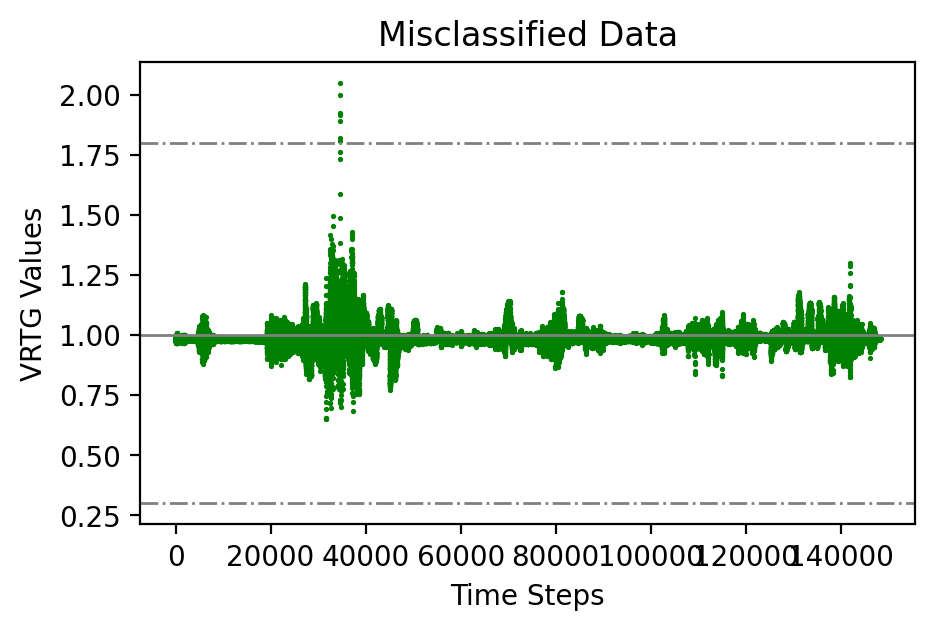

========= Flight ID: 35
2088273420200729B-5593.csv
Flight ID: 35, No Jump Segments Detected


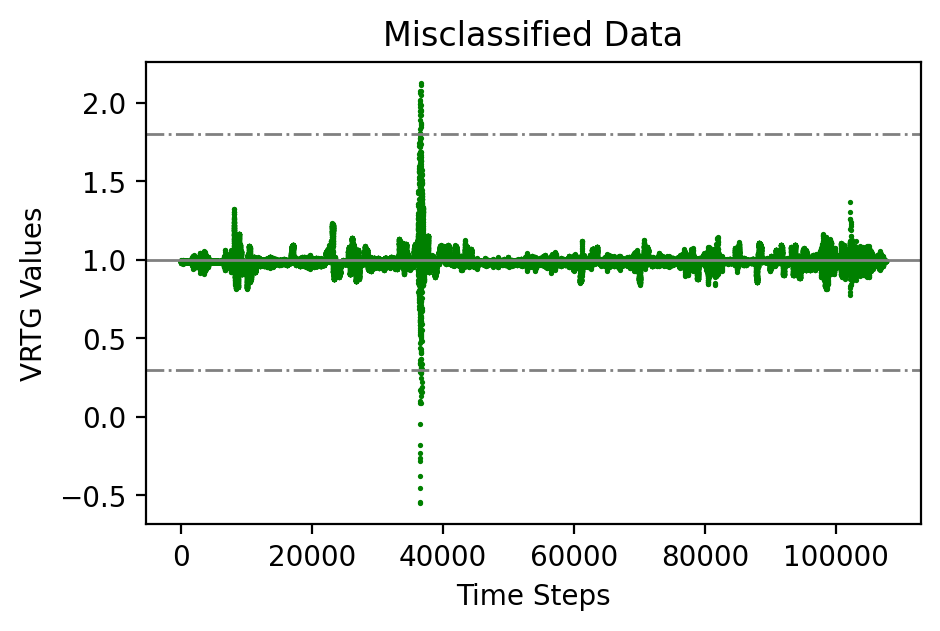

========= Flight ID: 36
2090639120200729B-206K.csv
Flight ID: 36, No Jump Segments Detected


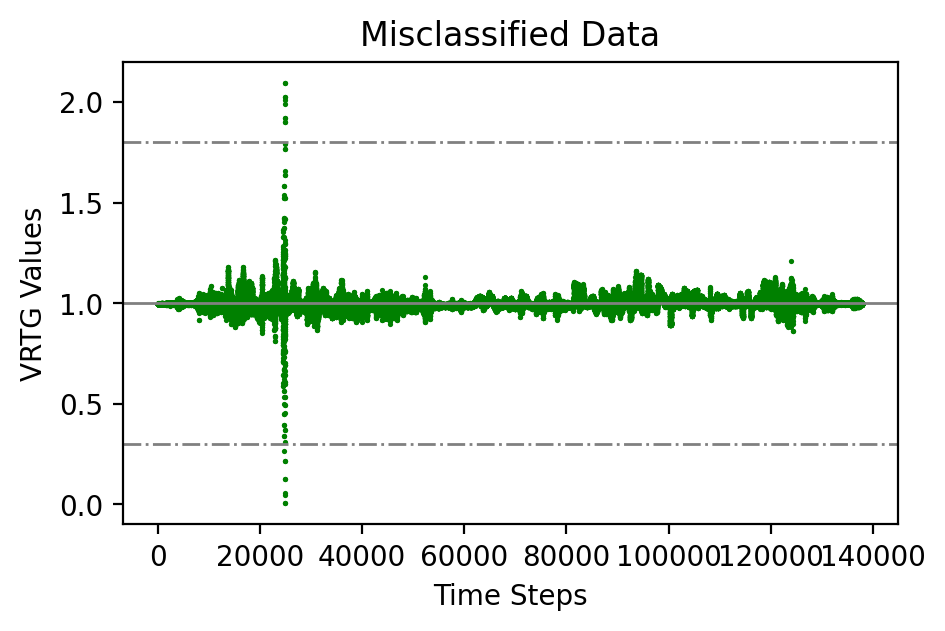

========= Flight ID: 98
4402745620250321053435.csv
Flight ID: 98, No Jump Segments Detected


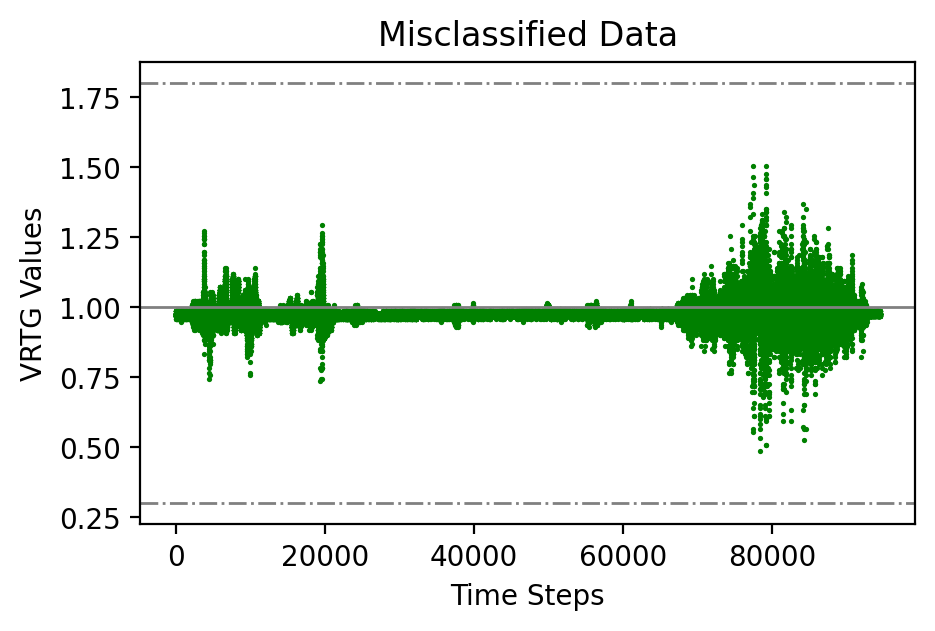

========= Flight ID: 99
4410998920250326102852.csv
Flight ID: 99, Jump Segments: [(958, 958)]


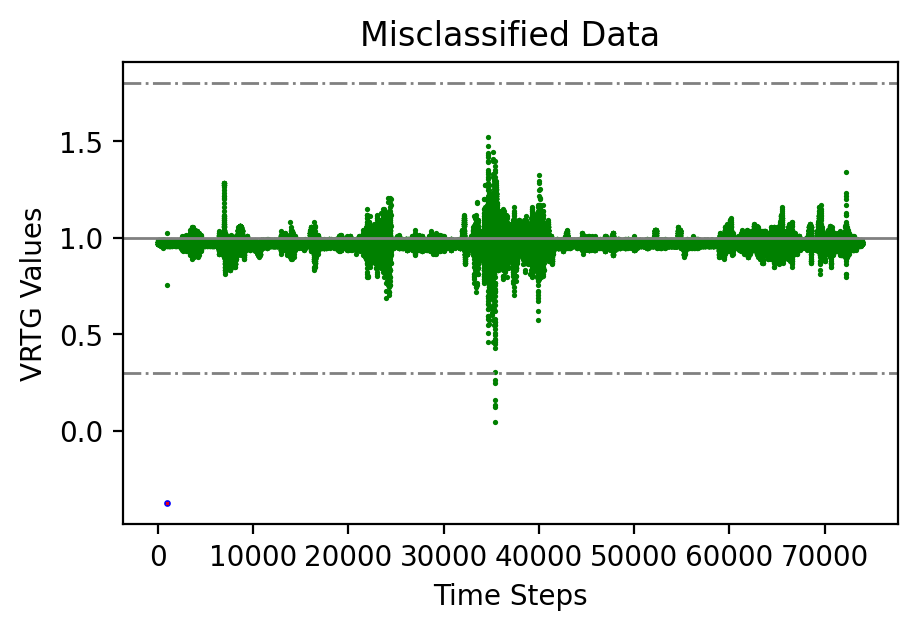

========= Flight ID: 100
4412756120250327142651.csv
Flight ID: 100, Jump Segments: [(1040, 1042), (37888, 37888)]


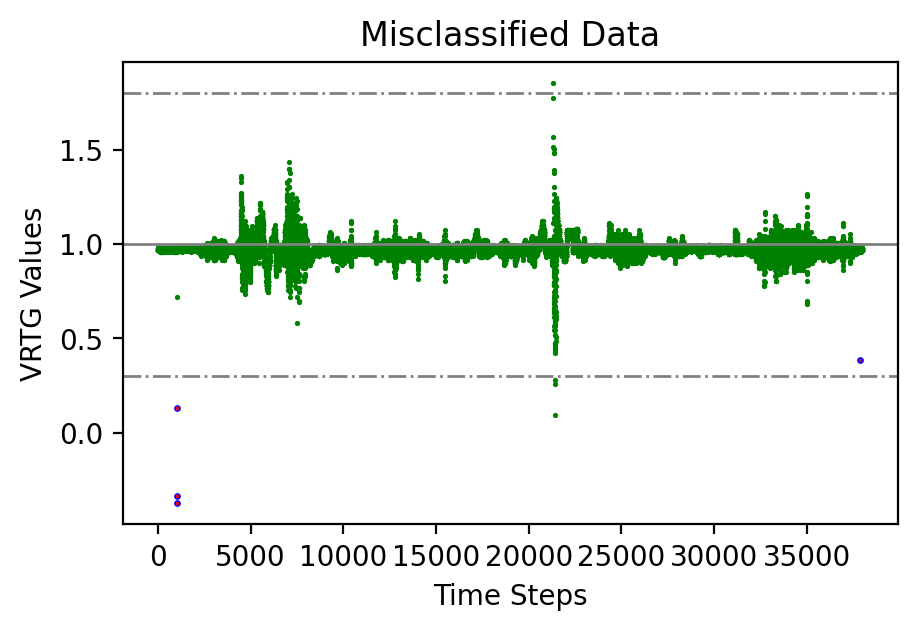

========= Flight ID: 101
4412801120250327135134.csv
Flight ID: 101, Jump Segments: [(878, 880), (63445, 63447)]


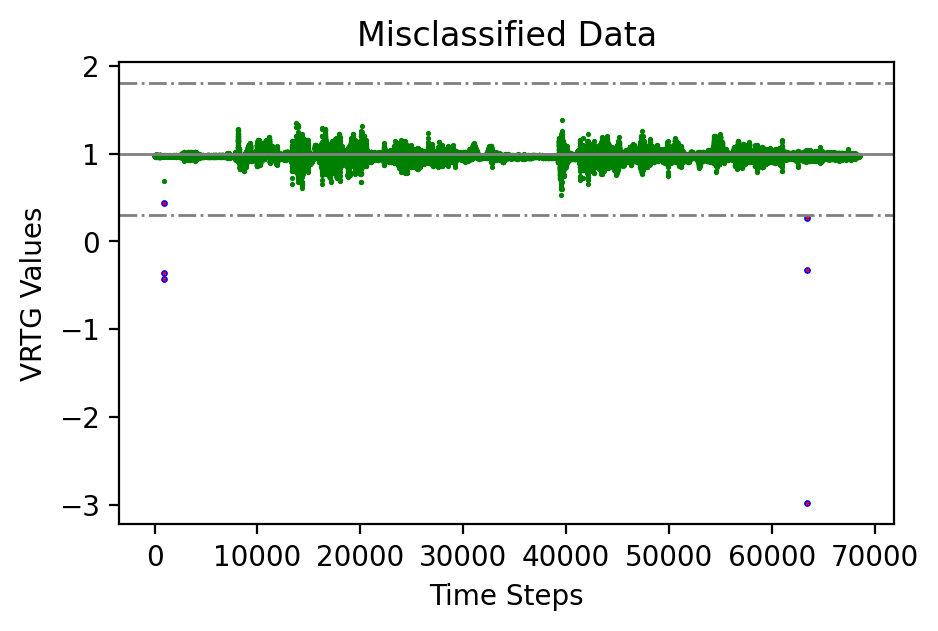

========= Flight ID: 102
4413544320250328023550-737.csv
Flight ID: 102, No Jump Segments Detected


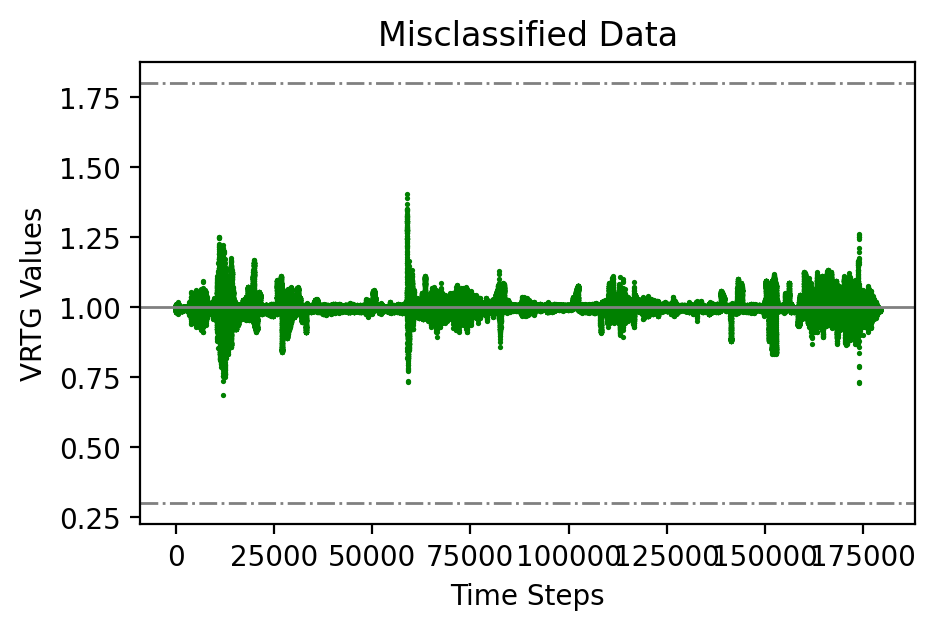

========= Flight ID: 103
4413602120250328032429.csv
Flight ID: 103, Jump Segments: [(85895, 85896)]


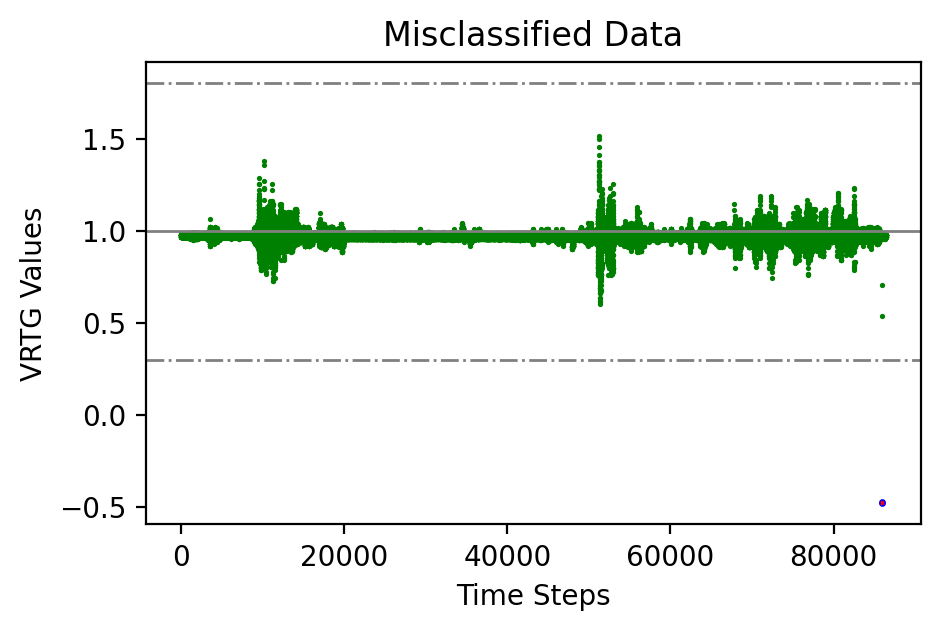

========= Flight ID: 104
4417355320250330090441.csv
Flight ID: 104, Jump Segments: [(620, 620), (56673, 56674)]


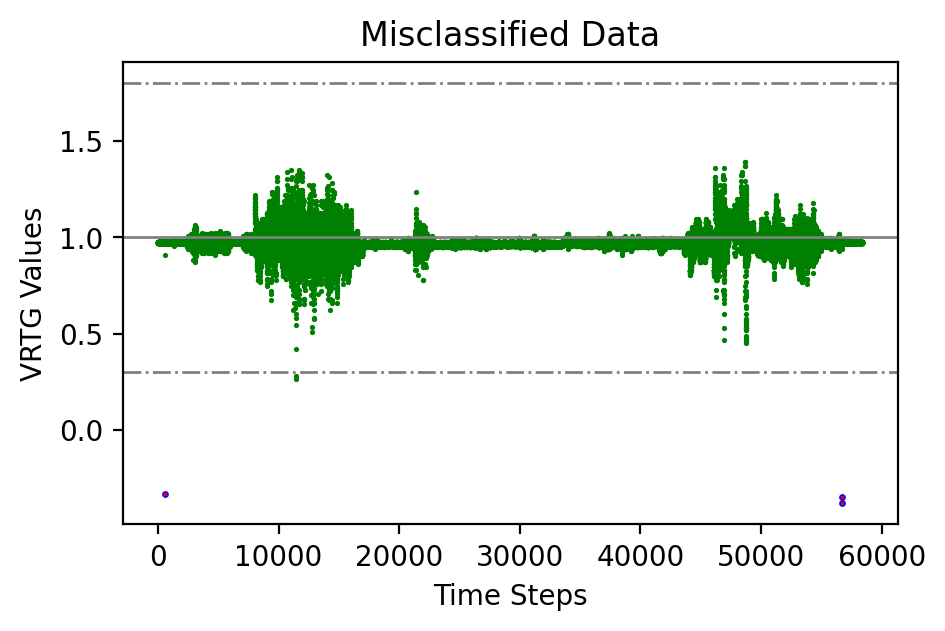

========= Flight ID: 105
4420275020250401050826.csv
Flight ID: 105, Jump Segments: [(322, 323), (51633, 51635)]


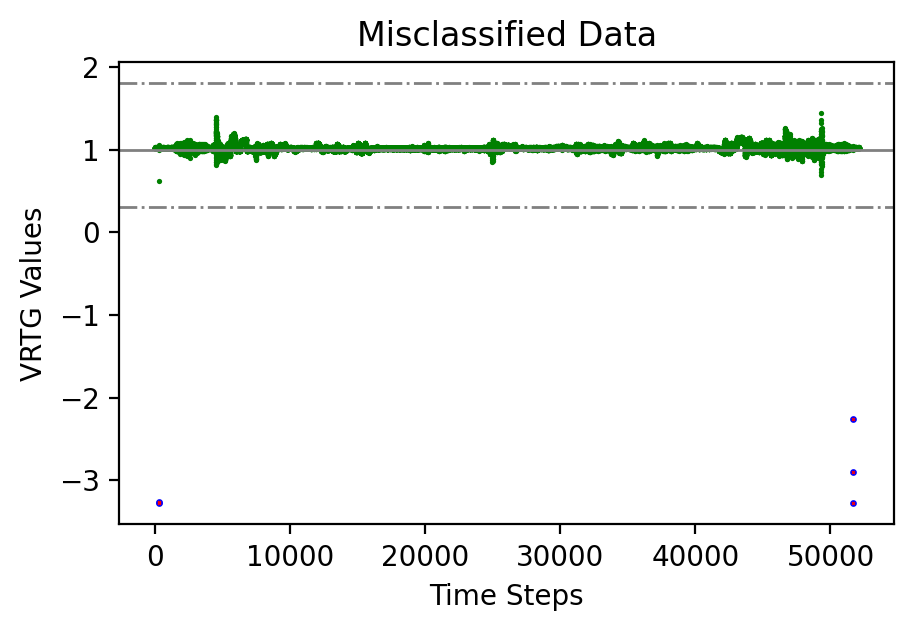

========= Flight ID: 106
4421043120250401055619.csv
Flight ID: 106, Jump Segments: [(123114, 123115)]


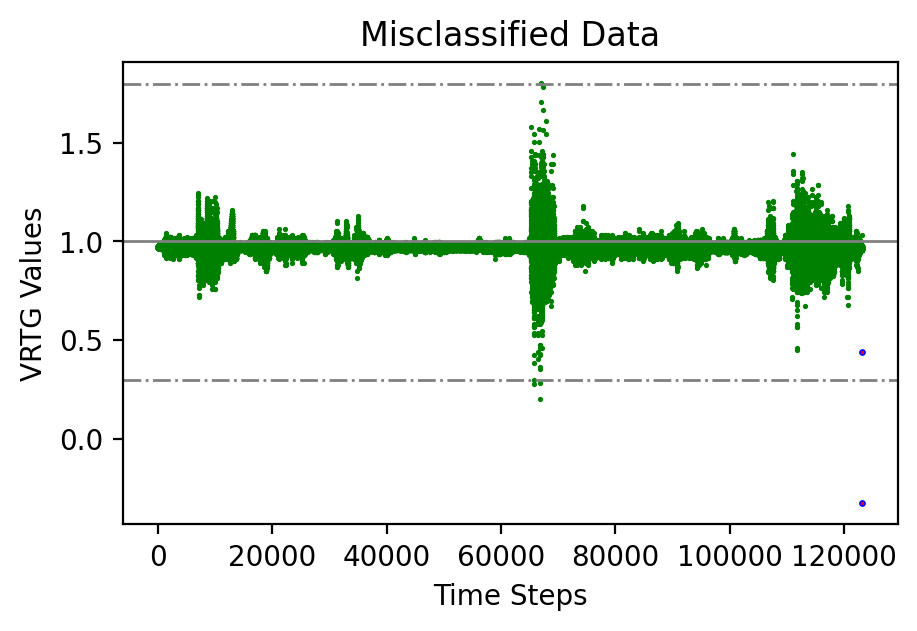

========= Flight ID: 107
4423846320250402103346.csv
Flight ID: 107, No Jump Segments Detected


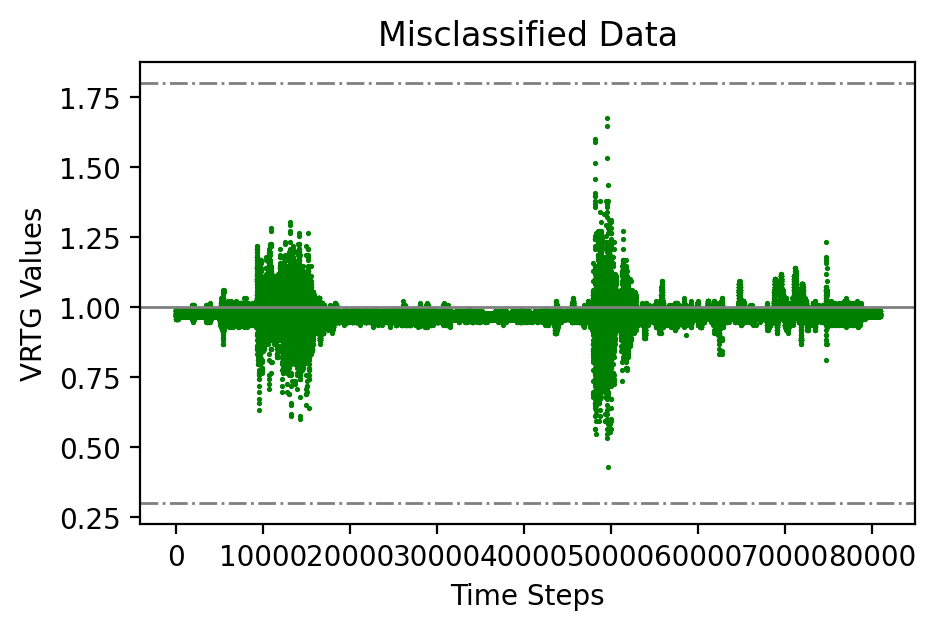

========= Flight ID: 108
4424000120250403055440.csv
Flight ID: 108, No Jump Segments Detected


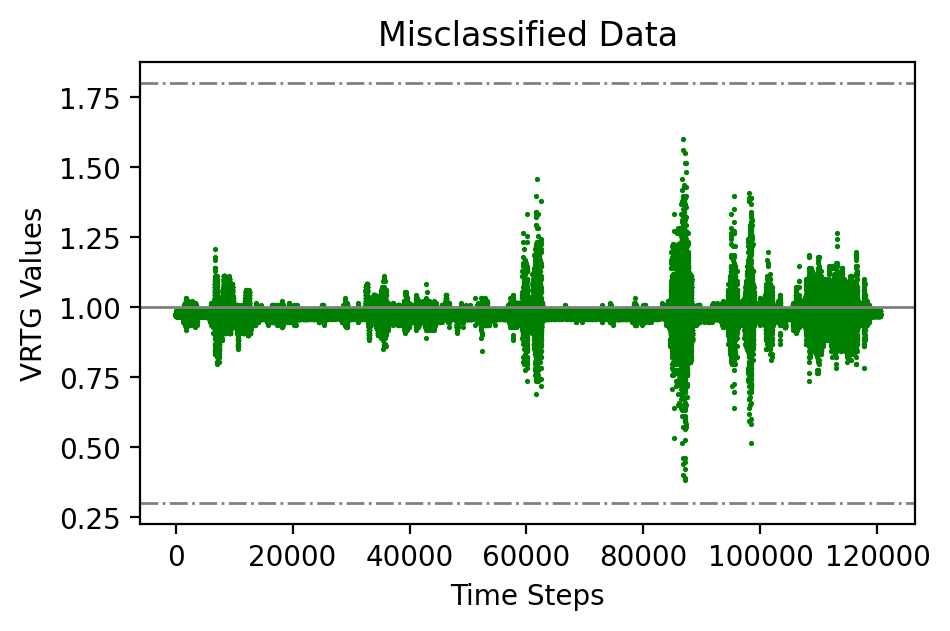

========= Flight ID: 109
4424309520250403130900.csv
Flight ID: 109, No Jump Segments Detected


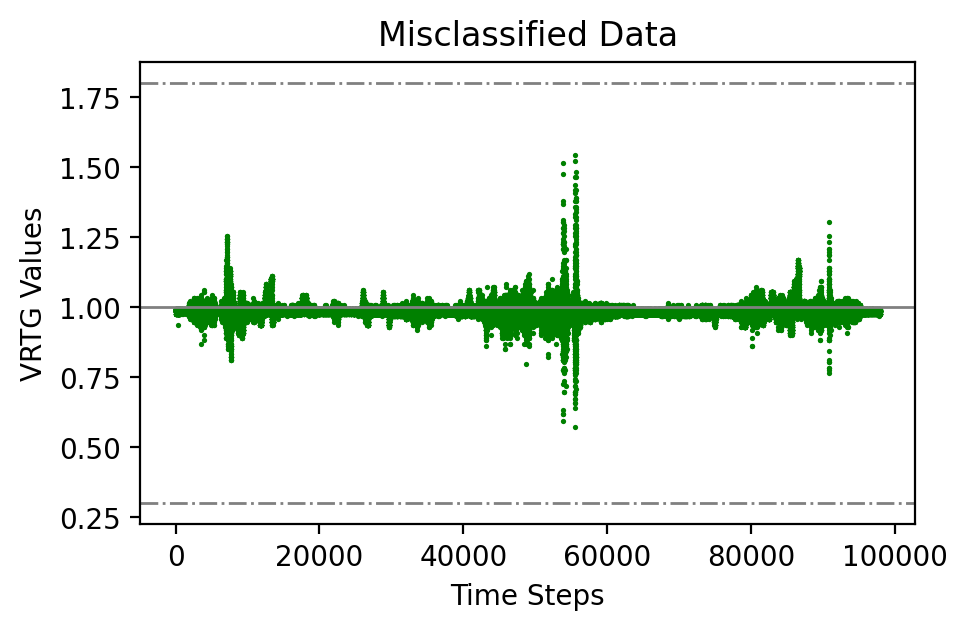

========= Flight ID: 110
4424719320250403105500.csv
Flight ID: 110, Jump Segments: [(431, 433)]


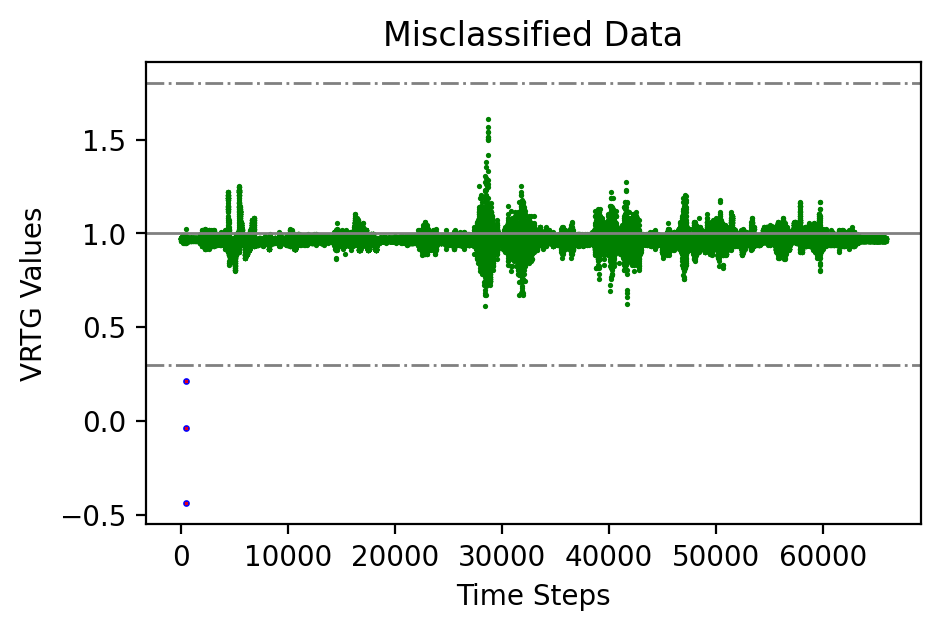

========= Flight ID: 111
4425315220250404042331.csv
Flight ID: 111, Jump Segments: [(26916, 26917), (36825, 36827), (116005, 116007)]


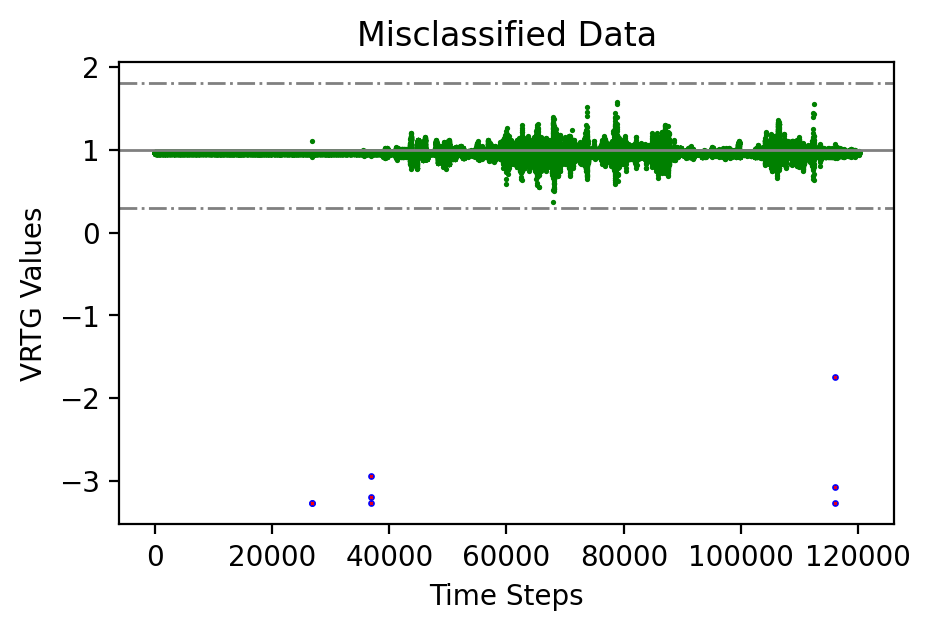

========= Flight ID: 112
4425622020250404092403.csv
Flight ID: 112, Jump Segments: [(305, 306), (75574, 75576)]


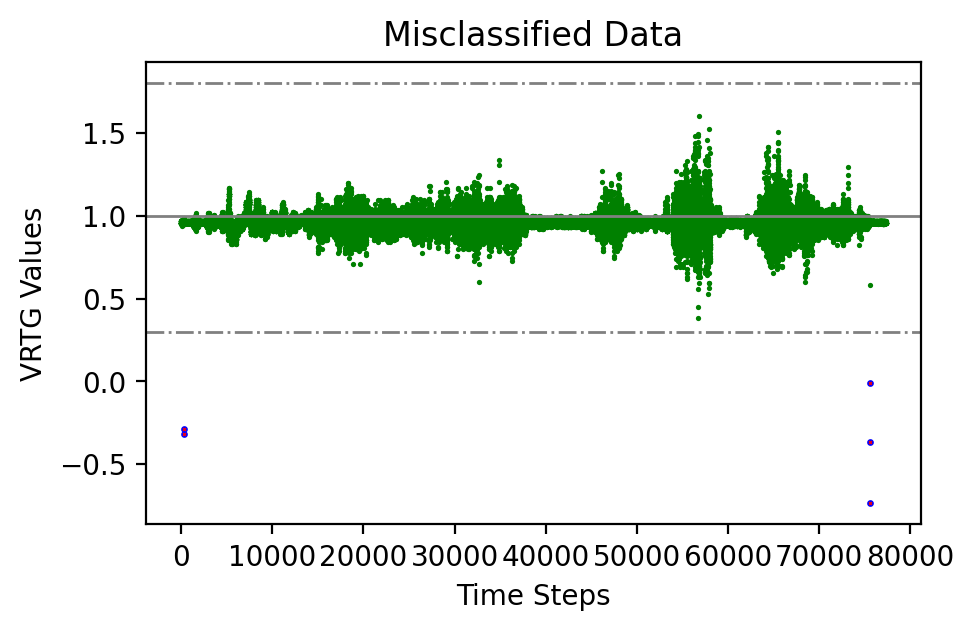

In [77]:
# 查看是否会将 normal 样本误判为 abnormal(jump)

for flight_id in test_normal_ids: # [14, 15, 16, 17, 18, 20, 22, 23]
    print(f"========= Flight ID: {flight_id}")

    flight_files_dict = {flight_id: file_name for flight_id, file_name in flight_files}
    file_name = flight_files_dict[flight_id]
    print(file_name)

    # data = train_data_aug.copy()
    data = test_data.copy()

    flight_data = data[data['flight_id'] == flight_id].reset_index(drop=True)
    vrtg = flight_data['VRTG']

    # segments = detect_jump_segments(vrtg)
    segments = detect_jump_segments_filtered(vrtg)
    if len(segments) > 0:
        print(f"Flight ID: {flight_id}, Jump Segments: {segments}")
        plot_jump(segments, flight_data, min_index=0, max_index=5000000)

        # 借机标数据
        # csv = pd.read_csv(os.path.join("data", file_name))

        # jump_index = []
        # for start, end in segments:
        #     jump_index.extend(range(start, end + 1))

        # csv.loc[csv['index'].isin(jump_index), ['status', 'type']] = ['abnormal', 'jump']

        # csv.to_csv(os.path.join("data", file_name), index=False)
        # print(f"-- Jump Segments Updated in CSV")

    else:
        print(f"Flight ID: {flight_id}, No Jump Segments Detected")
        plot_jump([], flight_data, min_index=0, max_index=5000000)
        # 仅绘制正常数据

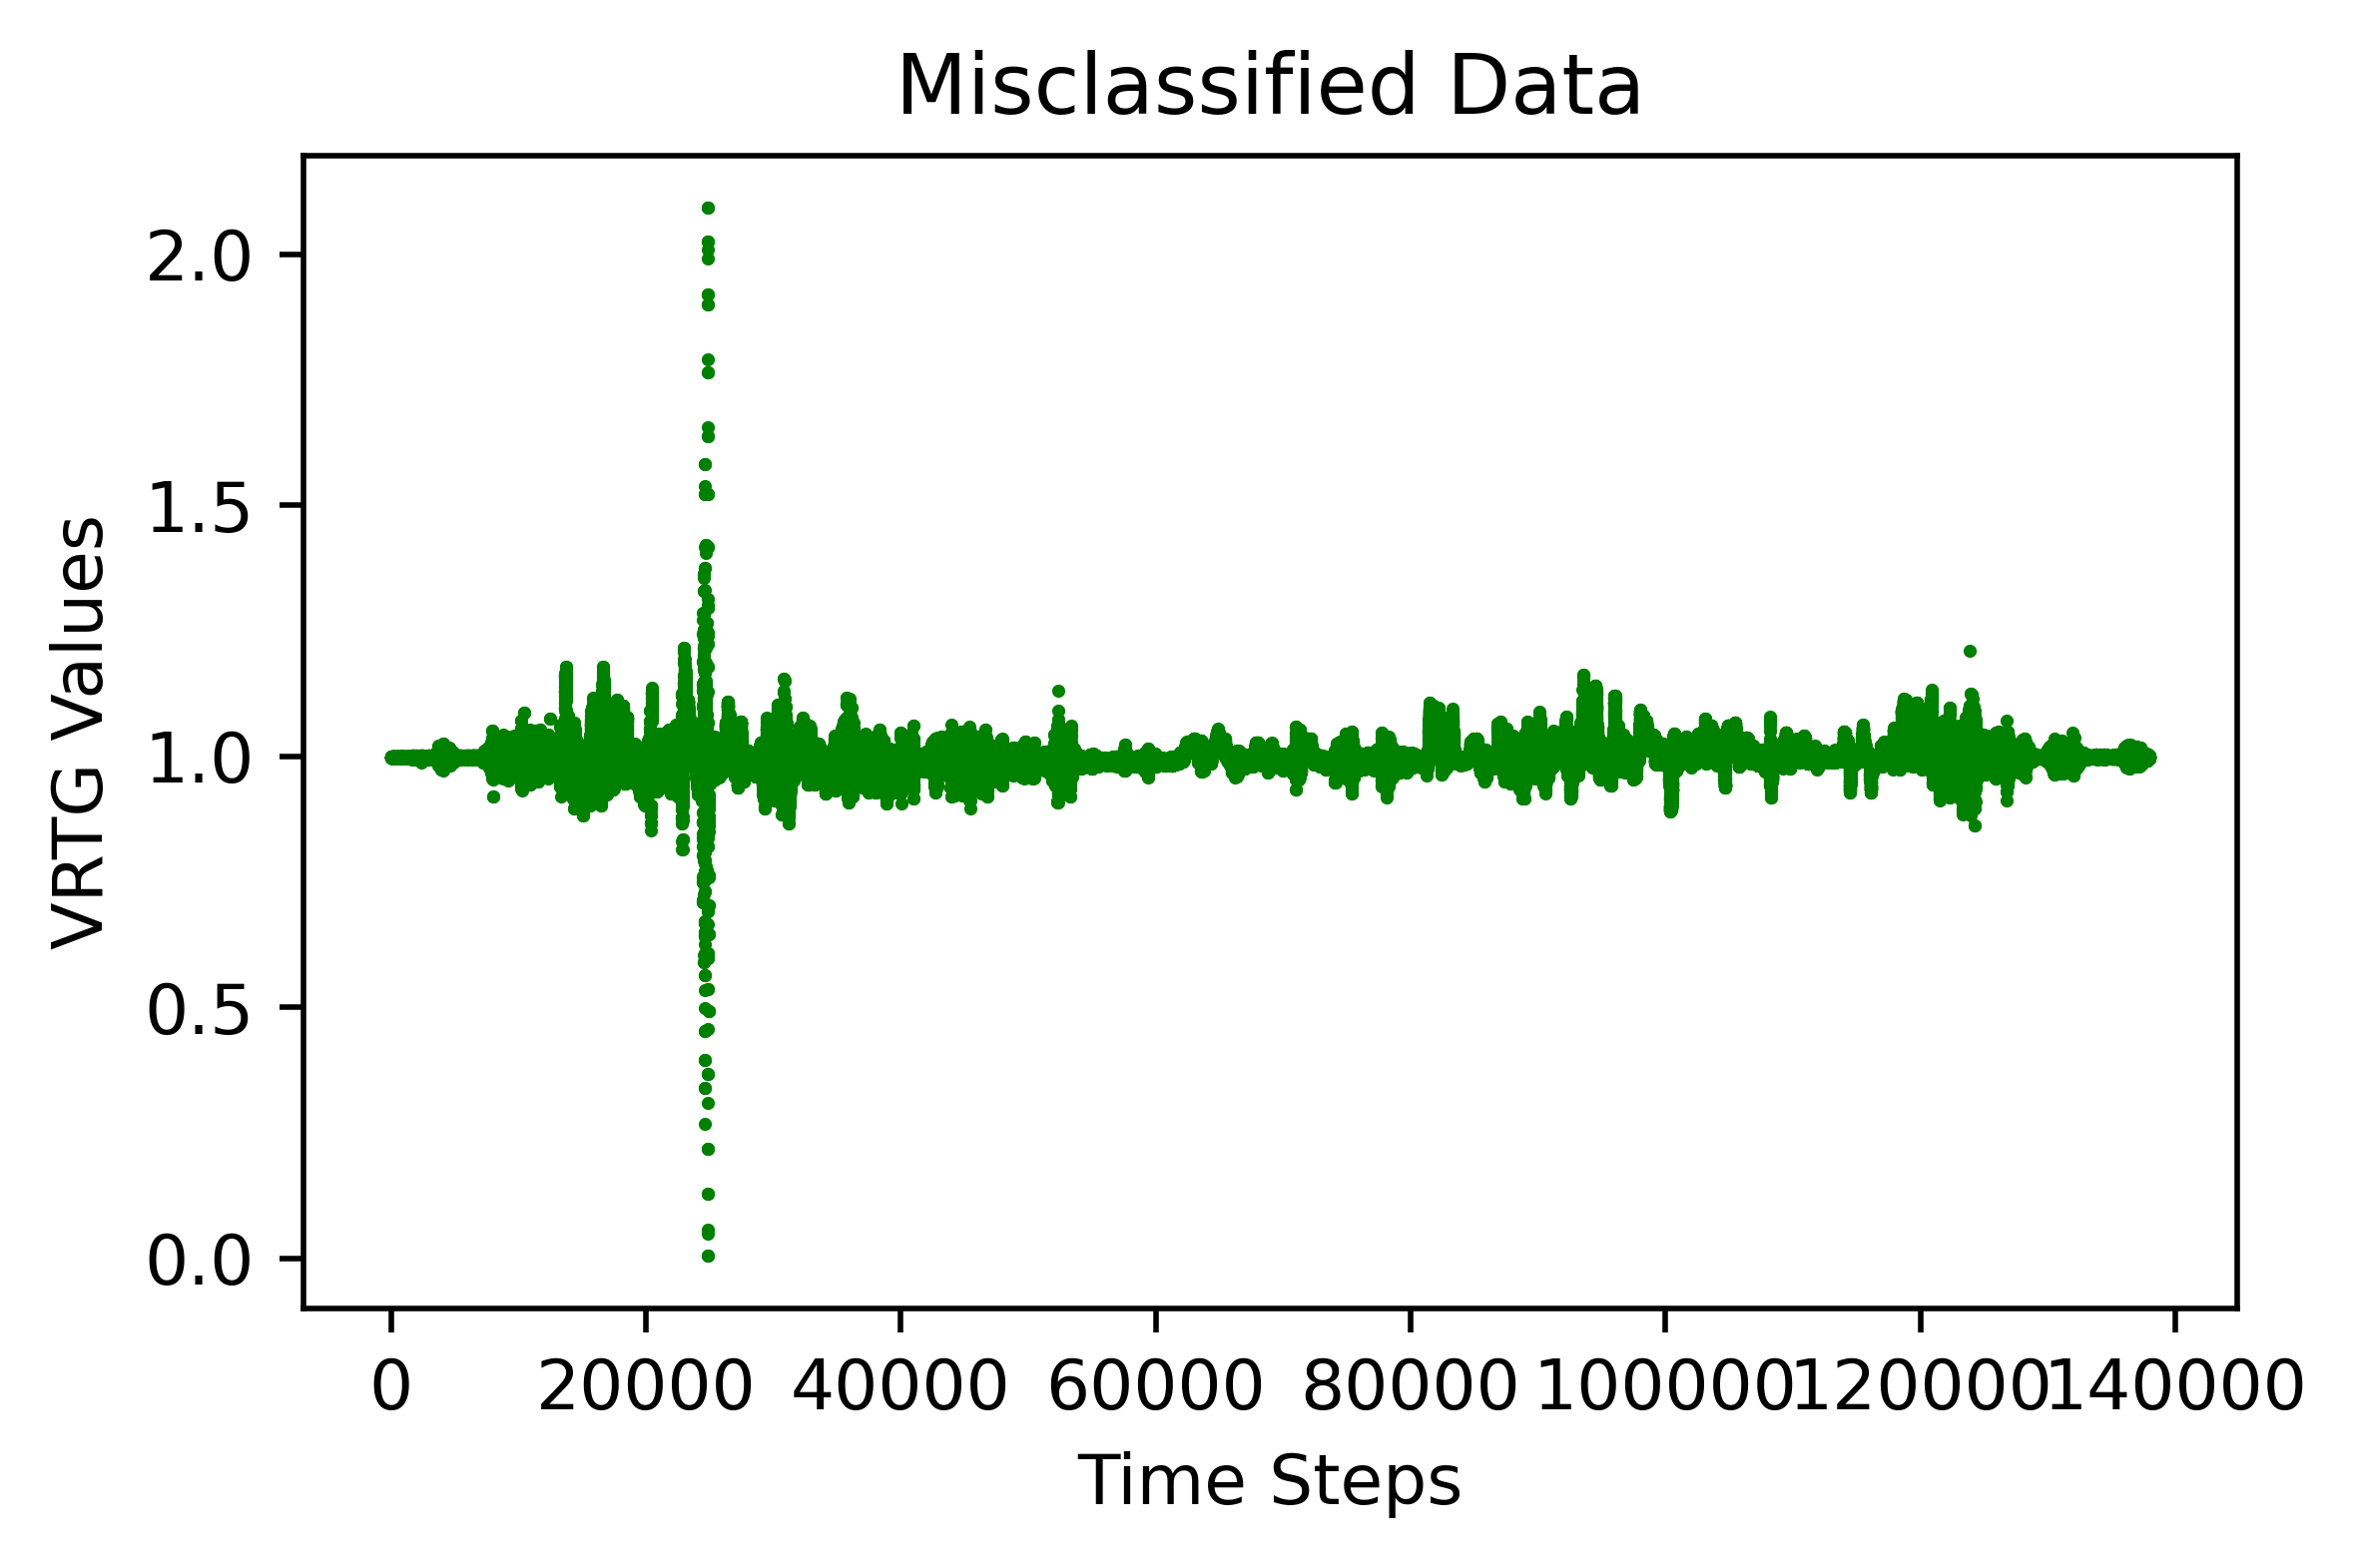

In [59]:
data = test_data.copy()
flight_id = 35

flight_data = data[data['flight_id'] == flight_id].reset_index(drop=True)
vrtg = flight_data['VRTG']

segments = detect_jump_segments(vrtg)

plot_jump(segments, flight_data, min_index=0, max_index=5000000)


In [48]:
flight_id = 15